# 05 · Power and Sample Size

Notebook 04 judged the tests. This one is the practical companion, and it exists to kill one
specific mistake:

> **"p = 0.23, so there is no effect."**

A non-significant result is not evidence of no effect. It is the absence of evidence, and the
absence can come from two completely different places: there really is nothing there, or there
is something there and you did not collect enough data to see it. Power analysis is what tells
those apart.

In [1]:
# Make the project importable whether this notebook is run from notebooks/ or the repo root.
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
from src.config import get_settings, save_results
from src.evaluation.comparison import build_registry
from src.evaluation.power import family_wise_error_rate, power_curve
from src.simulation.scenarios import make_scenario
from src.tests.welch import welch_test
from src.visualisation import plot_multiple_comparisons, plot_power_curve, save_figure

settings = get_settings()
alpha = settings.alpha
curve_reps = settings.notebooks.power_curve_reps
sizes = settings.grid.sample_sizes
registry = build_registry(settings)
figures: dict[str, str] = {}

print(f"sample sizes swept: {sizes}")
print(f"replications per point: {curve_reps:,}  (mc_se at power 0.5 = "
      f"{(0.25 / curve_reps) ** 0.5:.4f})")

sample sizes swept: [10, 20, 50, 100, 200]
replications per point: 2,000  (mc_se at power 0.5 = 0.0112)


## How much data does each test need?

A moderate effect — half a standard deviation — on clean normal data. Each line is one test;
the band is ±2 Monte Carlo standard errors.

In [3]:
normal_scenarios = [
    make_scenario(f"normal_n{n}", "normal", n_a=n, n_b=n, effect_d=0.5, settings=settings)
    for n in sizes
]
normal_curve = power_curve(
    registry, normal_scenarios, n_reps=curve_reps, alpha=alpha, seed=settings.seed
)
normal_curve.pivot(index="n_a", columns="test", values="power").round(3)

test,bayesian,bootstrap,mann_whitney,permutation,student,welch
n_a,,,,,,
10,0.150,0.174,0.158,0.186,0.186,0.184
20,0.336,0.346,0.342,0.354,0.358,0.356
50,0.692,0.698,0.683,0.700,0.702,0.702
100,0.936,0.937,0.928,0.934,0.938,0.938
200,0.999,0.999,0.998,0.999,0.999,0.999


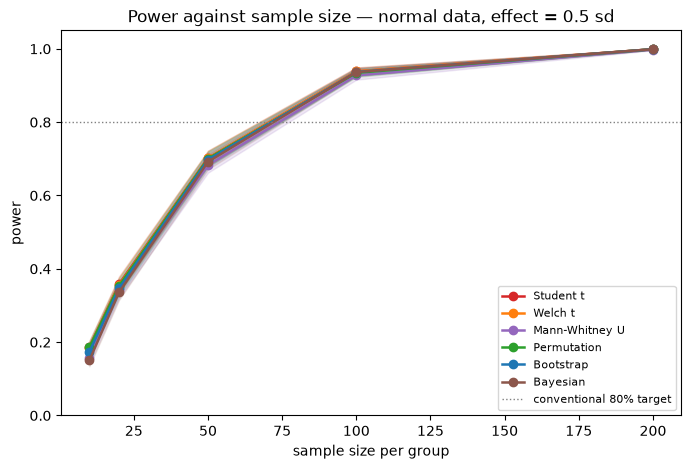

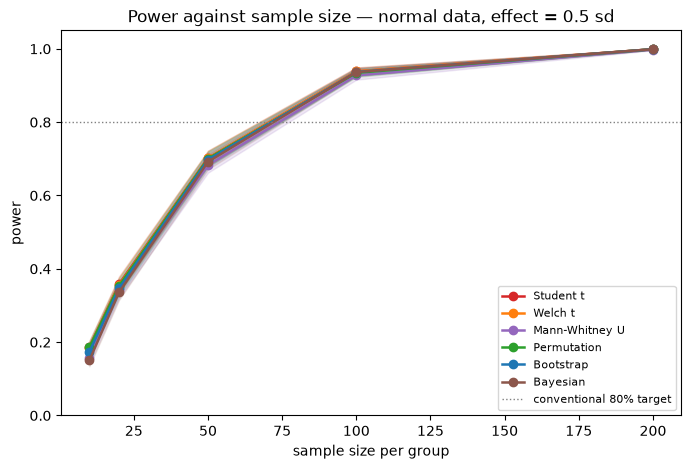

In [4]:
fig = plot_power_curve(
    normal_curve, title="Power against sample size — normal data, effect = 0.5 sd"
)
figures["power_curve_normal"] = save_figure(fig, "05_power_curve_normal")
fig

The practical reading: at n = 50 per group every test is near 70% power, and at n = 100 every
test is above 93%, so the 80% threshold falls between them — the classical analytic answer for
an effect of 0.5 sd is about 64 per group, and the simulation brackets it.

At n = 20 every test is below 40%. That means a real half-standard-deviation effect produces a
non-significant result roughly two times in three. If your experiment had 20 per arm and came
back "not significant", that is the most likely explanation, and it is not "no effect".

## The same effect on skewed data

Now the identical effect size on a right-skewed population.

In [5]:
skewed_scenarios = [
    make_scenario(f"skewed_n{n}", "lognormal", n_a=n, n_b=n, effect_d=0.5, settings=settings)
    for n in sizes
]
skewed_curve = power_curve(
    registry, skewed_scenarios, n_reps=curve_reps, alpha=alpha, seed=settings.seed
)
skewed_curve.pivot(index="n_a", columns="test", values="power").round(3)

test,bayesian,bootstrap,mann_whitney,permutation,student,welch
n_a,,,,,,
10,0.236,0.208,0.413,0.318,0.278,0.268
20,0.431,0.396,0.746,0.462,0.445,0.442
50,0.721,0.706,0.988,0.734,0.728,0.728
100,0.927,0.912,1.000,0.930,0.929,0.928
200,0.997,0.994,1.000,0.998,0.997,0.997


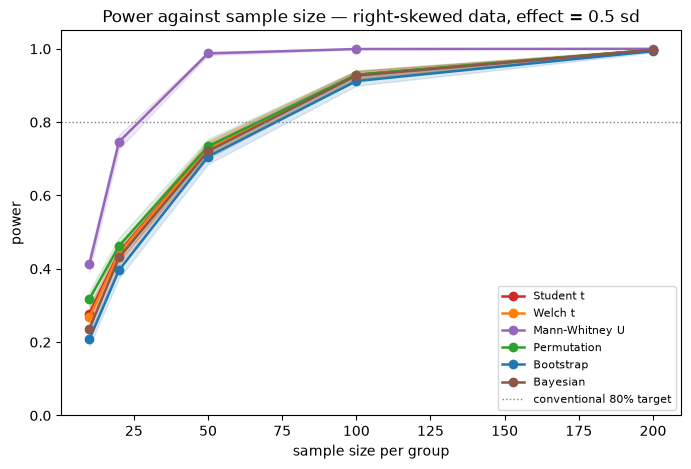

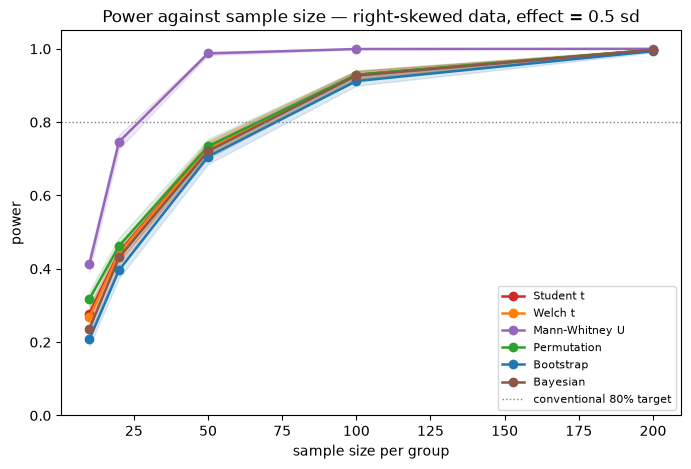

In [6]:
fig = plot_power_curve(
    skewed_curve, title="Power against sample size — right-skewed data, effect = 0.5 sd"
)
figures["power_curve_skewed"] = save_figure(fig, "05_power_curve_skewed")
fig

Two things worth stopping on.

**The tests separate here in a way they never do on normal data.** Mann-Whitney is far above the
mean-based tests, because under skew the ranks carry the signal that the mean is drowning in the
tail. That is the same result notebook 04 found, seen as a curve.

**These curves are higher than the normal ones, and that is not a claim that skew is good for
you.** It is an artifact of the currency: an effect of "0.5 standard deviations" on a lognormal
is a much larger separation of the *bulk* of the two distributions, because the standard
deviation being divided by has been inflated by the long right tail. Cohen's d is not portable
across distribution shapes. Compare tests within one panel; do not compare the panels.

## The other way to manufacture a discovery: test twenty things

Everything so far has assumed you run one test. Nobody runs one test. You run the experiment and
then check revenue, retention, session length, conversion, clicks, and fifteen other metrics.

Here are twenty comparisons on data where **nothing changed at all**, using a perfectly
calibrated Welch t-test.

In [7]:
null_scenario = make_scenario("multi", "normal", n_a=100, n_b=100, settings=settings)
family = family_wise_error_rate(
    welch_test,
    null_scenario,
    k=settings.notebooks.multiple_comparisons_k,
    trials=2000,
    alpha=alpha,
    seed=settings.seed,
)
print(f"each individual test is calibrated at α = {alpha}")
print(f"testing k = {family.k} metrics, none of which changed:")
print(f"  at least one 'significant': {family.any_significant_rate:.1%} of experiments")
print(f"  theoretical 1 - (1-α)^k   : {family.expected_rate:.1%}")
print(f"  average false alarms per experiment: {family.mean_significant:.2f}")

each individual test is calibrated at α = 0.05
testing k = 20 metrics, none of which changed:
  at least one 'significant': 64.2% of experiments
  theoretical 1 - (1-α)^k   : 64.2%
  average false alarms per experiment: 1.01


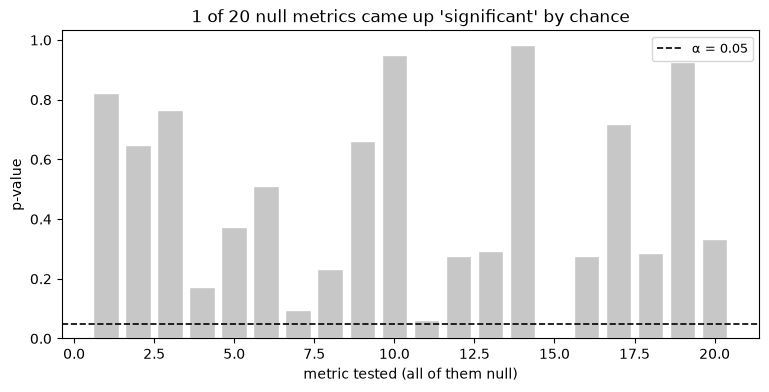

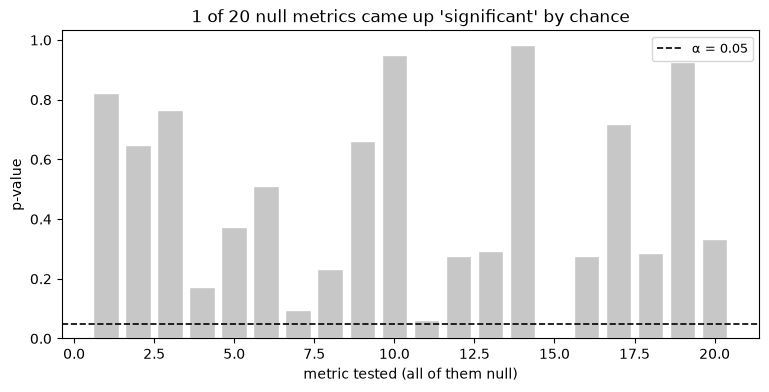

In [8]:
fig = plot_multiple_comparisons(family.p_values, alpha=alpha)
figures["multiple_comparisons"] = save_figure(fig, "05_multiple_comparisons")
fig

Two experiments in three will hand you a "significant" metric when the treatment did nothing.
No test in this project fixes that, because nothing is wrong with the tests — each one is
delivering exactly the 5% it promised. The error is in the arithmetic of asking twenty questions
and reporting the one that answered.

The fixes are a separate topic (Bonferroni, Benjamini–Hochberg, pre-registering the primary
metric), but the discipline is simple: **decide what you are testing before you look**.

## What we have established

- A non-significant result may mean "no effect" or "not enough data", and only a power analysis
  distinguishes them.
- Around 60–70 per group is the ballpark for a half-sd effect at 80% power on clean data.
- Under skew the tests separate sharply, and the rank test pulls ahead.
- Effect sizes in standard deviations are not comparable across distribution shapes.
- Testing 20 null metrics produces a false discovery about two times in three, using tests that
  are individually perfect.

Next: how to choose, in practice.

In [9]:
def at_least(frame, target):
    hit = frame[frame["power"] >= target]
    return int(hit["n_a"].min()) if len(hit) else None


summary = {
    "notebook": "05_power_and_sample_size",
    "settings": {"profile": settings.profile, "alpha": alpha, "n_reps": curve_reps,
                 "sample_sizes": sizes, "effect_d": 0.5, "seed": settings.seed},
    "power_curve_normal": normal_curve,
    "power_curve_skewed": skewed_curve,
    # Grid-limited: the smallest swept sample size that reached 80%, not an interpolated
    # requirement. With sizes [10, 20, 50, 100, 200] the true crossing sits between 50 and 100.
    "smallest_swept_n_reaching_80_percent_power": {
        "normal": {
            test: at_least(normal_curve[normal_curve["test"] == test], 0.8)
            for test in normal_curve["test"].unique()
        },
        "skewed": {
            test: at_least(skewed_curve[skewed_curve["test"] == test], 0.8)
            for test in skewed_curve["test"].unique()
        },
    },
    "multiple_comparisons": {
        "k": family.k,
        "trials": family.trials,
        "alpha": family.alpha,
        "any_significant_rate": family.any_significant_rate,
        "expected_rate": family.expected_rate,
        "mean_false_alarms": family.mean_significant,
    },
    "figures": figures,
    "claims": [
        "A non-significant result is not evidence of no effect; it may be evidence of too "
        "little data, and only a power analysis tells the two apart.",
        "On clean normal data an effect of 0.5 sd reaches ~70% power at 50 per group and "
        ">93% at 100 per group, bracketing the classical requirement of about 64 per group.",
        "At 20 per group that same effect is missed roughly two times in three by every test.",
        "Under skew the tests separate and the rank-based test pulls well ahead of the "
        "mean-based ones.",
        "Power curves are not comparable across population shapes, because Cohen's d divides "
        "by a standard deviation the skewed tail has inflated.",
        f"Testing {family.k} unchanged metrics with a perfectly calibrated test yields at least "
        f"one 'significant' result {family.any_significant_rate:.0%} of the time.",
    ],
}
print(save_results("05_power_and_sample_size", summary))

/workspaces/hypothesis_testing_arena/outputs/results/05_power_and_sample_size.json
